# Macroscopic optics with a response computed for each object direction

**Use case:** compute off-axis vector fields and a small distant-source scene
through centimetre-scale refracting and millimetre-scale reflecting surfaces at
$\lambda_0=193.368$ nm. Every incident direction gets its own spectral Fresnel
transformation on the actual surface. No convolution, invariant-shift assumption,
or translated on-axis point response is used to form these results.

This recovers and extends the earlier stigmatic single-surface use case to
off-axis illumination. It is not complete multi-element DUV transport. The
mirror is the dielectric reflection branch ($1\to1.5$), not a metal or coating.
The reference theories remain outside the implementation.

In [1]:
# Locate this checkout and initialize inline figures.

from pathlib import Path
import sys
import json
import time

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map
from examples.field_dependent_optics import configuration, response, WAVELENGTH
from vecdiff import DielectricInterface, plane_wave, sample_surface, interface_transform

style()

## 1. Define the two optical configurations

Both surfaces use
$$z(r)=\frac{cr^2}{1+\sqrt{1-(1+K)c^2r^2}}.$$
The exit diopter has $c=-0.1\,{\rm mm}^{-1}$, $K=-2.25$, aperture radius
12 mm, indices $1.5\to1$, and on-axis focus $z=20$ mm. The paraboloid has
$K=-1$, aperture radius 4 mm, and reflected focus $z=-5$ mm.
The drawn rays describe on-axis geometry; all field panels below come from
the surface radiation integral. Aperture diameters exceed 124,000 and 41,000
vacuum wavelengths respectively.

In [2]:
# Resolve both physical configurations before drawing or propagating fields.

kinds = ("refraction", "reflection")
geometries = {kind: configuration(kind) for kind in kinds}

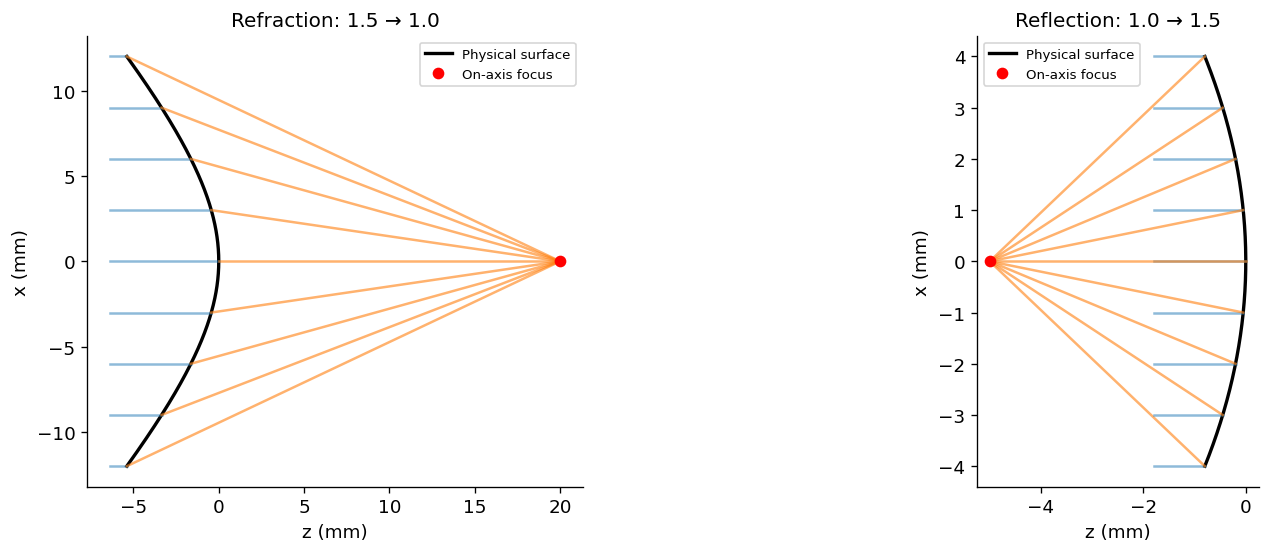

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")

for kind, ax in zip(kinds, axes):
    surface, n1, n2, aperture, focus, mapping = geometries[kind]
    rho = np.linspace(-aperture, aperture, 601)
    sag = surface.sag(abs(rho))
    ax.plot(sag, rho, "k", lw=2, label="Physical surface")

    for r in np.linspace(-aperture, aperture, 9):
        s = surface.sag(abs(r))
        ax.plot([min(sag) - 1, s], [r, r], color="tab:blue", alpha=0.5)
        ax.plot([s, focus[2]], [r, 0], color="tab:orange", alpha=0.6)

    ax.plot(focus[2], 0, "ro", label="On-axis focus")
    ax.set(
        xlabel="z (mm)",
        ylabel="x (mm)",
        title=f"{kind.capitalize()}: {n1.n} → {n2.n}",
        aspect="equal",
    )
    ax.legend(fontsize=8)

show(fig, "08_macroscopic_geometry")

## 2. Compute each off-axis response independently

For illumination angle $\theta$, the incident mode is
$k=n_1k_0(\sin\theta,0,\cos\theta)$ and $E_0=(\cos\theta,0,-\sin\theta)$.
We use a paraxial prediction only to choose the observation window. It does not
translate any field. Every observation is evaluated at its global position.

`evaluate_local` builds a fresh expansion of the fixed source currents for each
occupied observation patch. Its absolute $E$ and $\mathcal H$ error bounds cover
the Green-kernel expansion, not surface quadrature or dielectric trace accuracy.
The patch radius is $4\lambda_0$; source quadrature must converge separately for
every illumination and observation region.

In [4]:
# Choose the incident directions and source-surface quadrature.

angles = [0.0, 0.002, 0.01, 0.02]
source_nr = 128
source_nphi = 256

boundaries = {}

for kind in kinds:
    surface, n1, n2, aperture, focus, mapping = geometries[kind]
    interface = DielectricInterface(surface, n1, n2)
    samples = sample_surface(
        surface, (0, aperture), (0, 2 * np.pi), source_nr, source_nphi
    )
    boundaries[kind] = (interface, samples)


def incoming_wave(kind, angle_degrees):
    angle = np.deg2rad(angle_degrees)
    n1 = geometries[kind][1]
    return plane_wave(
        (np.sin(angle), 0, np.cos(angle)),
        (np.cos(angle), 0, -np.sin(angle)),
        wavelength=WAVELENGTH,
        medium=n1,
    )


x = np.linspace(-15, 15, 301) * WAVELENGTH
y = np.linspace(-4, 4, 101) * WAVELENGTH
X, Y = np.meshgrid(x, y)

fields = {}
lines = {}
radiations = {}
centers = {}
start = time.perf_counter()

for kind in kinds:
    for angle in angles:
        interface, samples = boundaries[kind]
        transformed = interface_transform(
            incoming_wave(kind, angle), interface, samples
        )
        rad = transformed.transmitted if kind == "refraction" else transformed.reflected

        # The paraxial mapping only locates the observation window.
        _, _, _, _, focus, mapping = geometries[kind]
        center = focus + np.array([mapping * np.tan(np.deg2rad(angle)), 0.0, 0.0])
        radiations[kind, angle] = rad
        centers[kind, angle] = center

        # Evaluate the independently transformed field at physical positions.
        result = rad.evaluate_local(
            center + np.stack((X, Y, 0 * X), axis=-1), radius=4 * WAVELENGTH
        )
        fields[kind, angle] = result.electric
        lines[kind, angle] = np.sum(abs(result.electric[len(y) // 2]) ** 2, axis=-1)

print(
    f"Computed {2 * len(angles) * X.size:,} vector observations for eight distinct surface transformations in {time.perf_counter() - start:.2f} s"
)

Computed 243,208 vector observations for eight distinct surface transformations in 8.54 s


**Focal observation planes:** x–y at each surface's image-centre z.
The top row is refraction at z = 20 mm; the bottom is reflection at z = −5 mm.

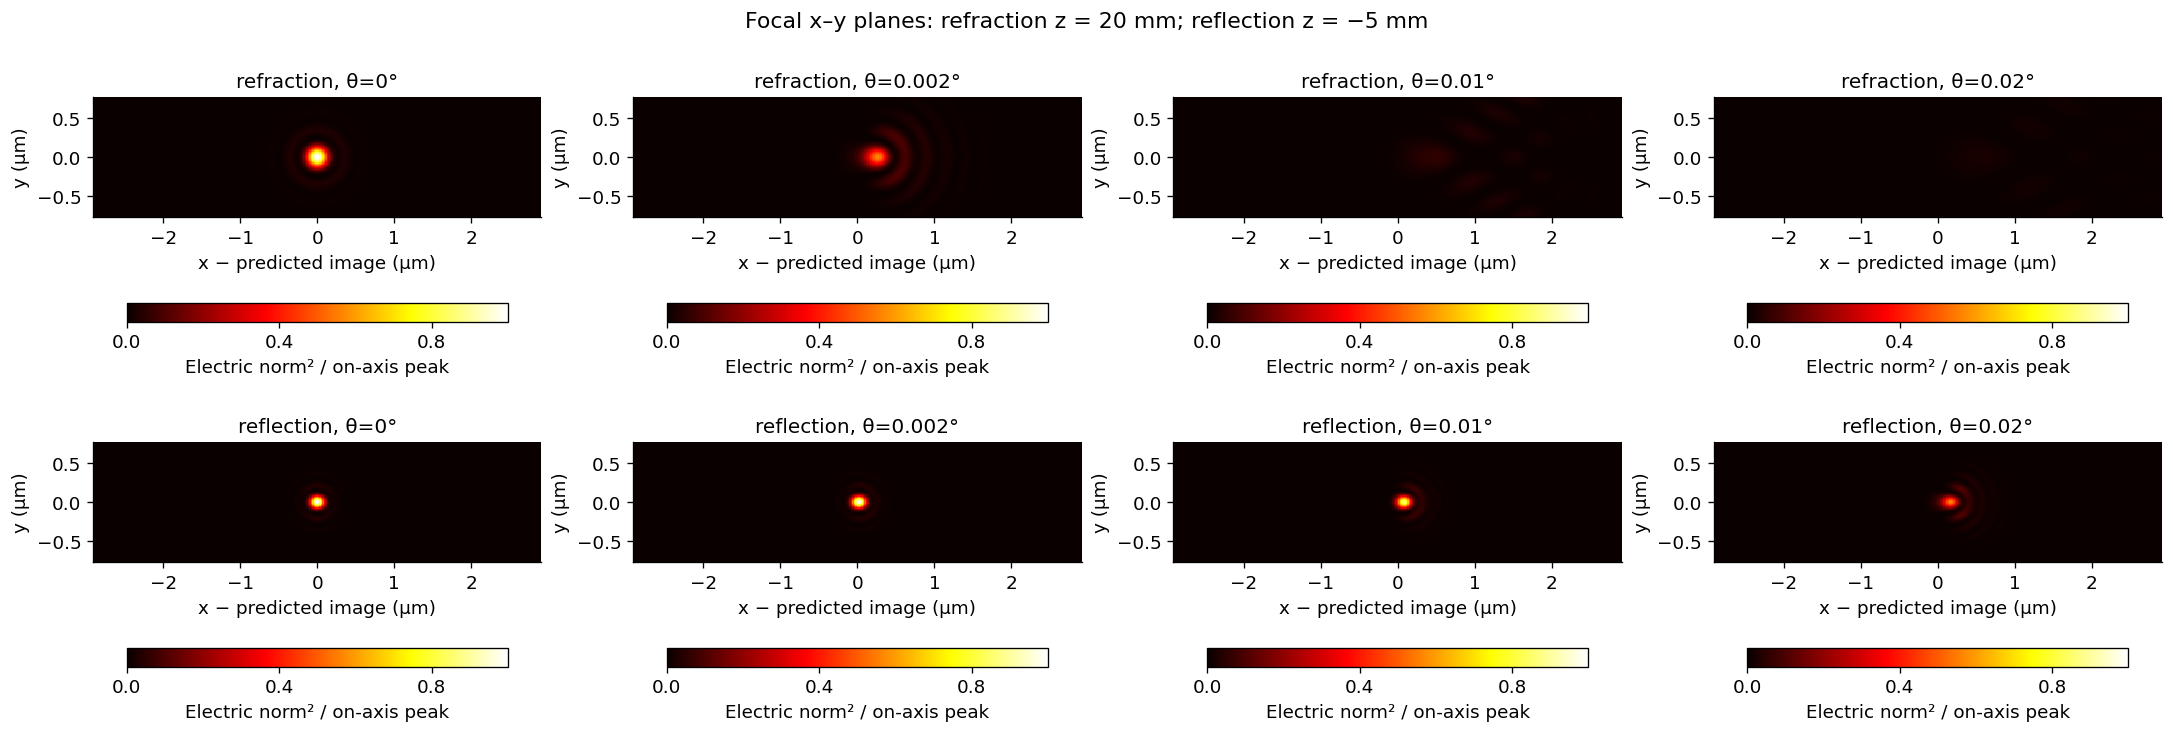

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6), layout="constrained")
fig.suptitle("Focal x–y planes: refraction z = 20 mm; reflection z = −5 mm")

for j, kind in enumerate(["refraction", "reflection"]):
    peak = np.sum(abs(fields[kind, 0.0]) ** 2, axis=-1).max()

    for ax, angle in zip(axes[j], angles):
        scalar_map(
            fig,
            ax,
            np.sum(abs(fields[kind, angle]) ** 2, axis=-1) / peak,
            x * 1e3,
            y * 1e3,
            f"{kind}, θ={angle:g}°",
            xlabel="x − predicted image (µm)",
            ylabel="y (µm)",
            label="Electric norm² / on-axis peak",
            vmax=1,
        )

show(fig, "08_field_dependent_spots")

## 3. Compare with a shifted on-axis template, without using it as a model

The blue curve is a fresh calculation at the stated angle; the dashed curve is
the on-axis result in the predicted shifted coordinate frame. No individual
peak normalization hides throughput or peak changes. The mismatch includes
both image displacement beyond the paraxial prediction and shape changes.

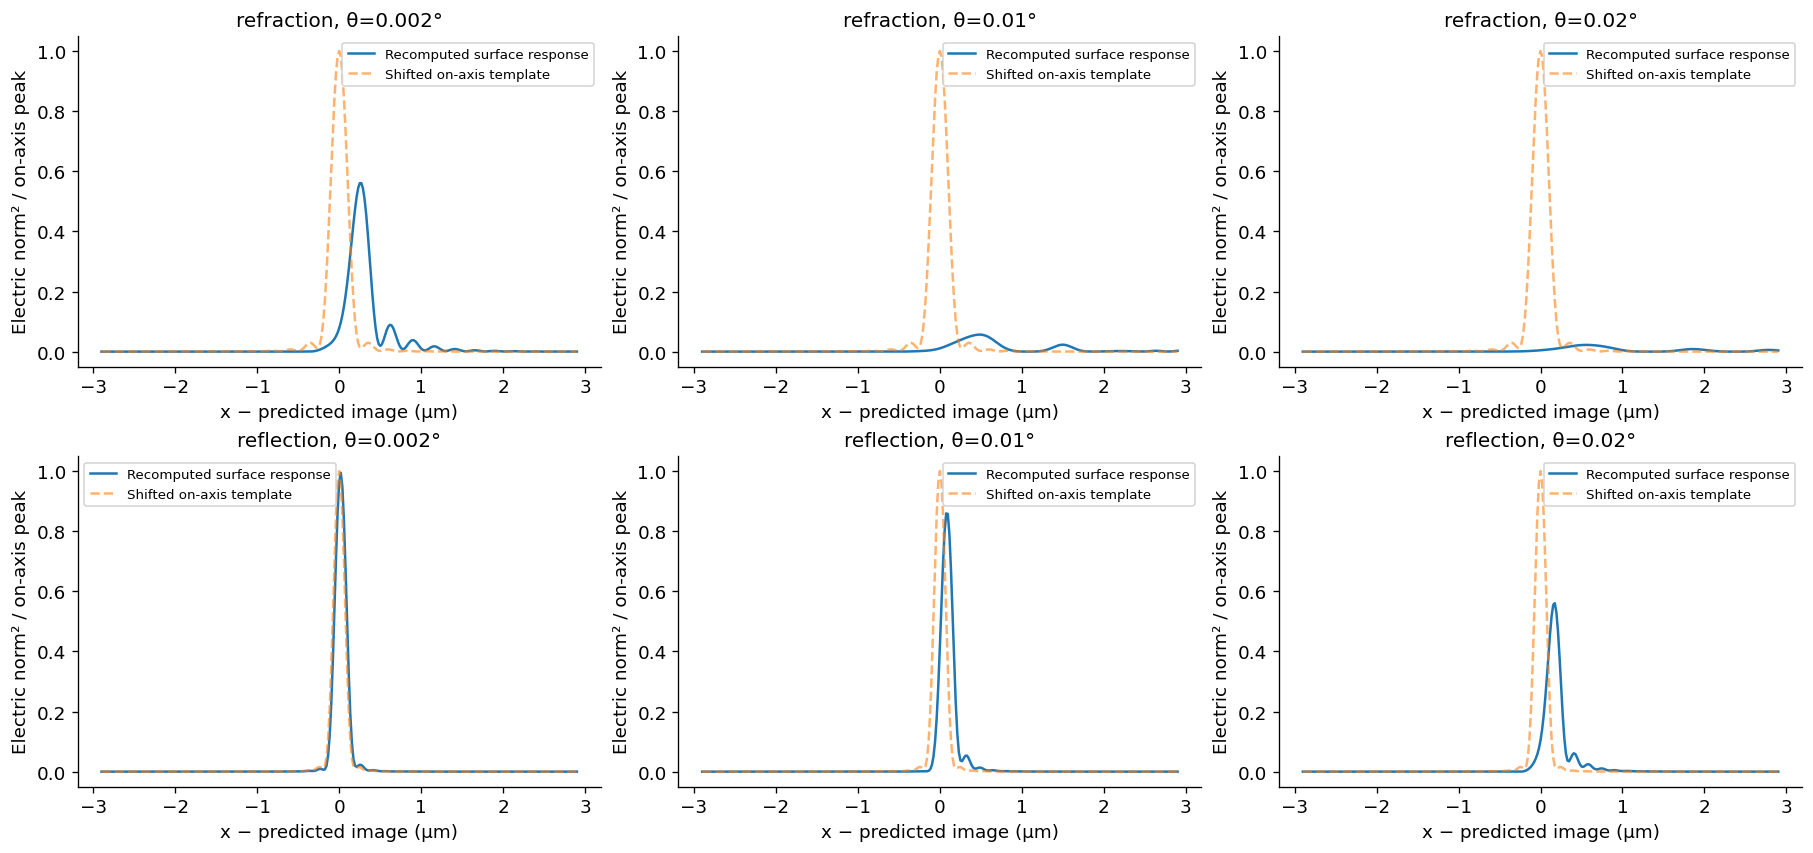

In [6]:
# Compare recomputed off-axis responses with shifted on-axis profiles.

fig, axes = plt.subplots(2, 3, figsize=(15, 7), layout="constrained")

for row, kind in enumerate(["refraction", "reflection"]):
    peak = lines[kind, 0.0].max()

    for ax, angle in zip(axes[row], angles[1:]):
        ax.plot(x * 1e3, lines[kind, angle] / peak, label="Recomputed surface response")
        ax.plot(
            x * 1e3,
            lines[kind, 0.0] / peak,
            "--",
            alpha=0.6,
            label="Shifted on-axis template",
        )
        ax.set(
            xlabel="x − predicted image (µm)",
            ylabel="Electric norm² / on-axis peak",
            title=f"{kind}, θ={angle:g}°",
        )
        ax.legend(fontsize=8)

show(fig, "08_shift_comparison")

## 4. Observe the off-axis image in two distinct planes

The refracting conic at $0.002^\circ$ already departs strongly from its stigmatic
on-axis image. Meridional coordinates are physical offsets from the predicted
focus. Ellipses show the transverse polarization, with low-intensity pixels
excluded; longitudinal electric energy is shown separately.

In [7]:
# Select one source direction and retain the on-axis normalization.

kind = "refraction"
angle = 0.002
rad = radiations[kind, angle]
center = centers[kind, angle]
peak = np.sum(abs(fields[kind, 0.0]) ** 2, axis=-1).max()

### Meridional plane: x–z at y = 0

This longitudinal slice passes through the predicted image centre. The
vertical axis is the physical offset $z-z_{center}$, not a transverse y axis.

In [8]:
z = np.linspace(-10, 10, 151) * WAVELENGTH
xm = np.linspace(-6, 9, 151) * WAVELENGTH
XM, Z = np.meshgrid(xm, z)
meridional = rad.evaluate_local(
    center + np.stack((XM, 0 * XM, Z), axis=-1), radius=4 * WAVELENGTH
).electric

**Meridional map:** electric norm in the x–z slice at y = 0.

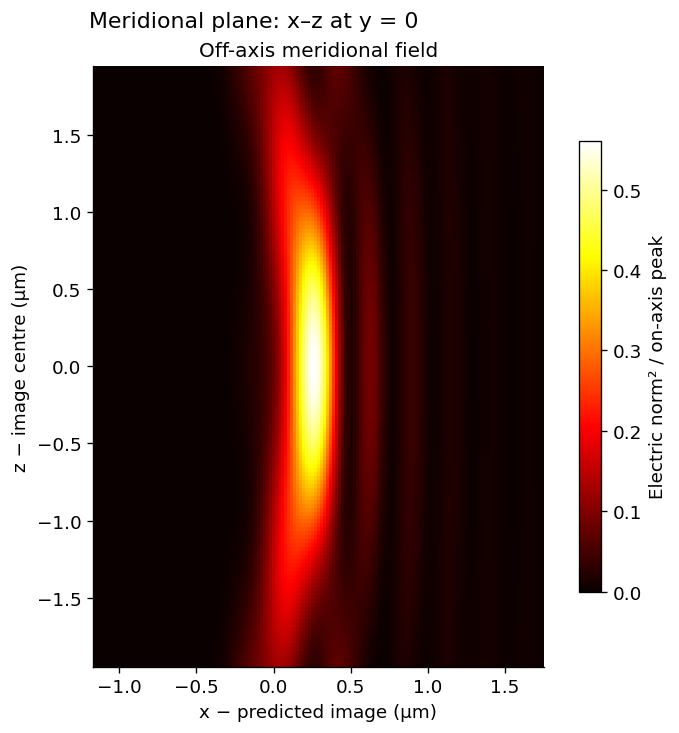

In [9]:
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
fig.suptitle("Meridional plane: x–z at y = 0")
scalar_map(
    fig,
    ax,
    np.sum(abs(meridional) ** 2, axis=-1) / peak,
    xm * 1e3,
    z * 1e3,
    "Off-axis meridional field",
    xlabel="x − predicted image (µm)",
    ylabel="z − image centre (µm)",
    label="Electric norm² / on-axis peak",
)
show(fig, "08_off_axis_meridional_field")

### Focal observation plane: x–y at z = image centre

The focal field below is evaluated at fixed z. Both plot axes are transverse
offsets from the predicted image centre; it is separate from the x–z slice.

In [10]:
e = fields[kind, angle]

**Focal-plane maps:** longitudinal electric component and transverse
polarization in x–y at the image-centre z coordinate.

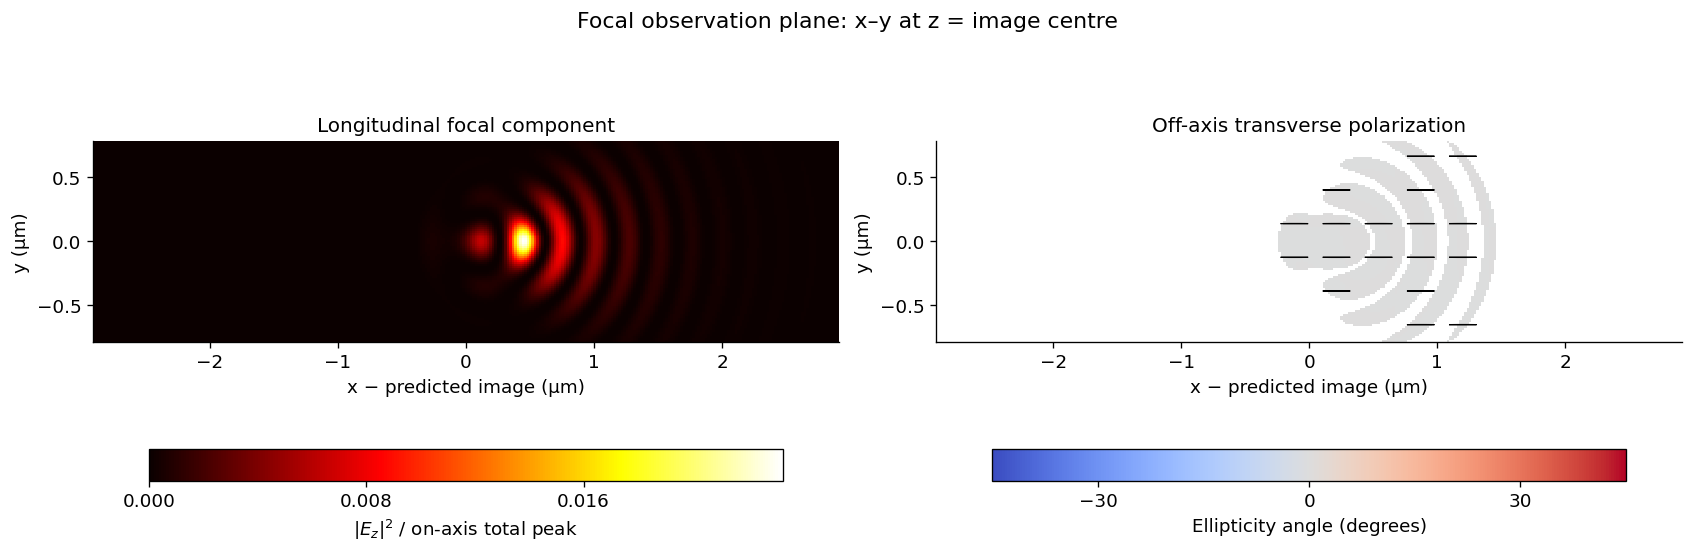

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), layout="constrained")
fig.suptitle("Focal observation plane: x–y at z = image centre")
scalar_map(
    fig,
    axes[0],
    abs(e[..., 2]) ** 2 / peak,
    x * 1e3,
    y * 1e3,
    "Longitudinal focal component",
    xlabel="x − predicted image (µm)",
    ylabel="y (µm)",
    label=r"$|E_z|^2$ / on-axis total peak",
)
polarization_map(
    fig, axes[1], e, x * 1e3, y * 1e3, title="Off-axis transverse polarization"
)
axes[1].set_xlabel("x − predicted image (µm)")
show(fig, "08_off_axis_focal_fields")

## 5. Form a scene by propagating each source, then combine fields

Three equal-strength distant points at $-0.002^\circ,0,+0.002^\circ$ illuminate
the exit diopter. They are evaluated on the **same global image coordinates**.
Mutually incoherent sources give $I=\sum_j w_j|E_j|^2$; phase-locked sources give
$I=|\sum_j\sqrt{w_j}e^{i\phi_j}E_j|^2$, here $w_j=1/3$, $\phi_j=0$.
Equal illumination strength does not imply equal image-plane peak intensity.
This small scene demonstrates field-dependent imaging directly; an extended
lithographic mask through a full multi-element system remains a separate task.

In [12]:
# Add independent source fields coherently or incoherently for a scene.

scene_x = np.linspace(-3.5, 3.5, 301) * 1e-3
scene_y = np.linspace(-0.8, 0.8, 101) * 1e-3
SX, SY = np.meshgrid(scene_x, scene_y)
scene_points = np.stack((SX, SY, 20 + 0 * SX), axis=-1)
scene_fields = []

for angle in [-0.002, 0.0, 0.002]:
    rad, center = response("refraction", angle)
    scene_fields.append(
        rad.evaluate_local(scene_points, radius=4 * WAVELENGTH).electric
    )

scene_fields = np.asarray(scene_fields)
incoherent = np.mean(np.sum(abs(scene_fields) ** 2, axis=-1), axis=0)
coherent = np.sum(abs(np.sum(scene_fields, axis=0) / np.sqrt(3)) ** 2, axis=-1)
normalization = max(incoherent.max(), coherent.max())

**Read the result:** Coherent and incoherent scene images use different field combinations.

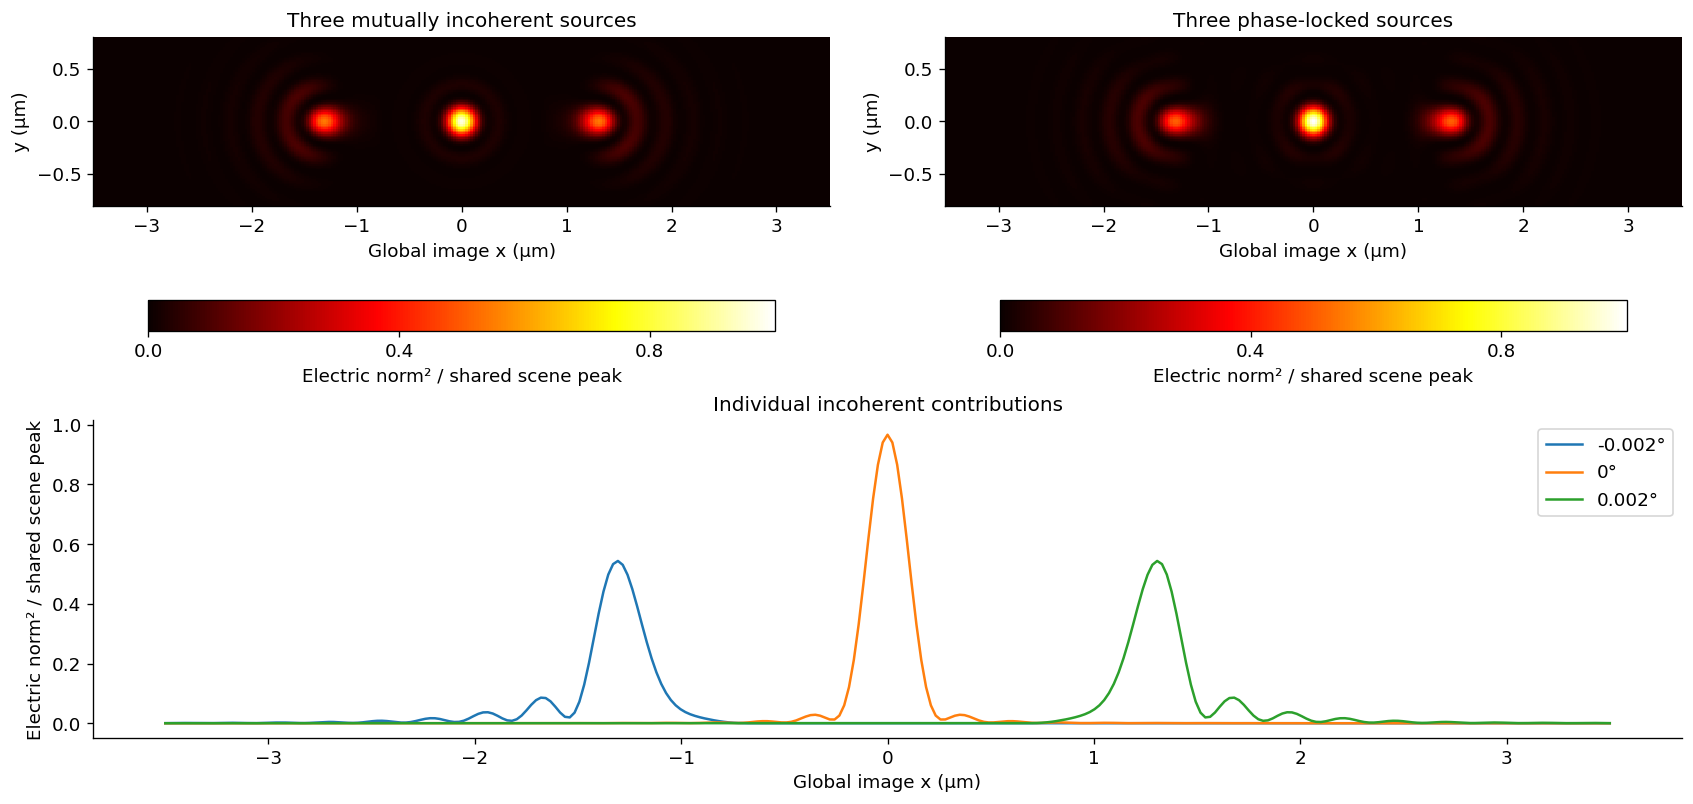

In [13]:
# Keep the two physical maps together and give the lineout its own full-width row.
fig = plt.figure(figsize=(14, 7), layout="constrained")
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.3])
axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[1, :]),
]

for ax, values, title in zip(
    axes[:2],
    [incoherent, coherent],
    ["Three mutually incoherent sources", "Three phase-locked sources"],
):
    scalar_map(
        fig,
        ax,
        values / normalization,
        scene_x * 1e3,
        scene_y * 1e3,
        title,
        xlabel="Global image x (µm)",
        ylabel="y (µm)",
        label="Electric norm² / shared scene peak",
        vmax=1,
    )

for field, angle in zip(scene_fields, [-0.002, 0.0, 0.002]):
    axes[2].plot(
        scene_x * 1e3,
        np.sum(abs(field[len(scene_y) // 2]) ** 2, axis=-1) / (3 * normalization),
        label=f"{angle:g}°",
    )

axes[2].set(
    xlabel="Global image x (µm)",
    ylabel="Electric norm² / shared scene peak",
    title="Individual incoherent contributions",
)
axes[2].legend()
show(fig, "08_direct_scene")

## 6. Verify the numerical calculation at held-out global positions

Direct dyadic-Green evaluation is independent of the local expansion. Doubling
radial and azimuthal source resolution checks oscillatory surface quadrature.
Neither comparison validates the local Fresnel boundary approximation itself;
notebook 07 tests that separate physical requirement.

In [14]:
# Check kernel bounds and source quadrature against stored benchmarks.

checks = []

# Check fresh E/H fields before reading stored benchmark rows.
for kind, angle in [("refraction", 0.002), ("reflection", 0.02)]:
    rad = radiations[kind, angle]
    center = centers[kind, angle]
    held = center + WAVELENGTH * np.array(
        [[-9, 0, -3], [-2, 1, 2], [0, 0, 0], [3, -1, -2], [11, 0, 3]]
    )
    fast = rad.evaluate_local(held, radius=4 * WAVELENGTH)
    full = rad.evaluate(held)
    finer, _ = response(kind, angle, nr=256, nphi=512)
    fine = finer.evaluate(held)
    relative = lambda a, b: (
        np.linalg.norm(np.concatenate(a, axis=-1) - np.concatenate(b, axis=-1))
        / np.linalg.norm(np.concatenate(b, axis=-1))
    )
    kernel = relative((fast.electric, fast.magnetic), full)
    quadrature = relative(full, fine)
    assert (
        np.max(np.linalg.norm(fast.electric - full[0], axis=-1))
        <= fast.electric_error_bound
    )
    assert (
        np.max(np.linalg.norm(fast.magnetic - full[1], axis=-1))
        <= fast.magnetic_error_bound
    )
    assert quadrature < 1e-6
    checks.append((kind, kernel, quadrature))
    print(
        f"{kind}: relative E/H kernel error={kernel:.3e}; source-quadrature change={quadrature:.3e}; absolute bounds passed"
    )

refraction: relative E/H kernel error=1.372e-06; source-quadrature change=8.801e-12; absolute bounds passed


reflection: relative E/H kernel error=6.164e-06; source-quadrature change=3.813e-12; absolute bounds passed


**Next step:** Cross-check the fresh kernel bounds against stored cases.

In [15]:
benchmark = json.loads(
    (root / "benchmarks/results/field_dependent_optics.json").read_text()
)

# Require every stored case to satisfy absolute kernel bounds.
for row in benchmark["cases"]:
    assert (
        row["absolute_kernel_bounds_passed"]
        and row["surface_quadrature_relative_EH_change"] < 1e-6
    )

**What is established:** direct field-dependent macroscopic single-surface
refraction and dielectric reflection, vector focal and meridional fields, and
coherent/incoherent source combination without shift invariance. The reported
speed applies to these smooth-phase near-focus patches and source samplings.
Larger fields can require much finer source quadrature; a fast NUFFT alone does
not resolve aliased surface phase. General extended surface-to-surface transport,
complete instrument imaging, and uniformly verified curved-boundary accuracy
remain pending. No claim of an exact or fully validated DUV instrument is made.